# Single Pixel Imaging

1. [x] load actual scene image
2. generate random matrices for Digital Mirror Device (DMD)
3. multiply image with random matrices to take Single Pixel Imaging samples 
4. attempt to recreate image from SPI samples

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import PIL

from sklearn.linear_model import LinearRegression, LassoCV
from PIL import Image

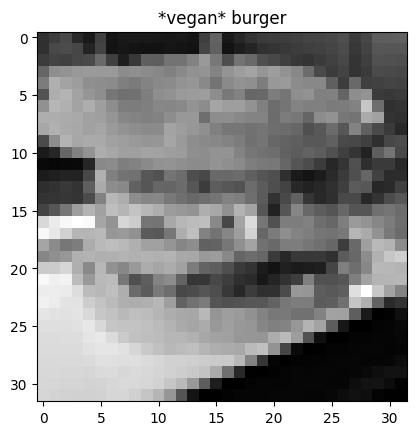

In [20]:
# read image and convert to grey scale
im = Image.open("vegan-burger.jpg").convert("L").crop(box=(0+300,0,1080+300,1080)).resize((32, 32), Image.BICUBIC)
plt.imshow(np.asarray(im), cmap="grey")
plt.title("*vegan* burger");

In [3]:
x = np.asarray(im).flatten() / 255

In [4]:
x.shape

(1024,)

## 2. Generate DMD Sampling Matrices

We will generate random matrices that control, if the individual mirrors of the DMD reflect the scene light towards the sensor or not.

In [5]:
phi = np.random.randint(2, size=(len(x), len(x)))

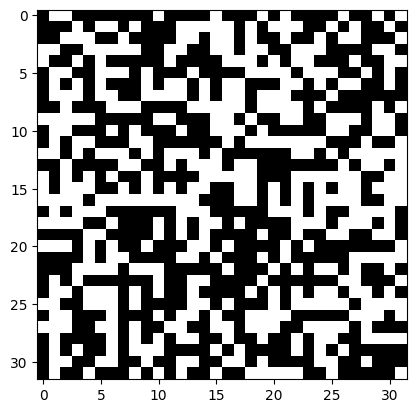

In [ ]:
plt.imshow(phi[0].reshape(32,32), cmap="binary");

## 3. Simulate single pixel sensor observations

In [7]:
# this is the signal that our single pixel sensor measures!
# optionally, add noise
y = phi @ x
noise = np.random.normal(0, 0.001 * y.std(), size=len(y))
y += noise

In [8]:
# 
y[0]

np.float64(223.56823319114562)

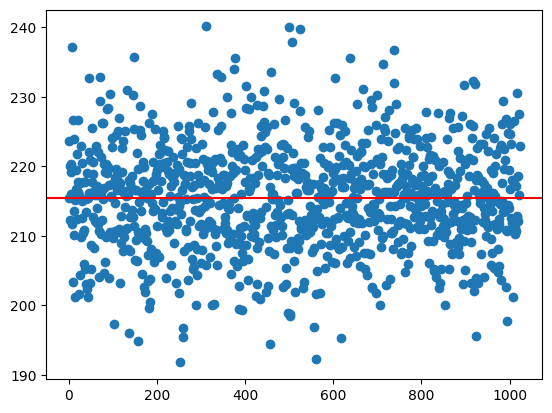

In [9]:
plt.scatter(np.arange(len(y)), y)
plt.axhline(y.mean(), c="red")

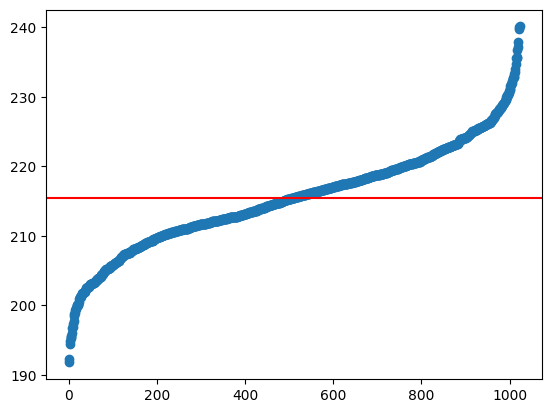

In [10]:
plt.scatter(np.arange(len(y)), np.sort(y))
plt.axhline(y.mean(), c="r")

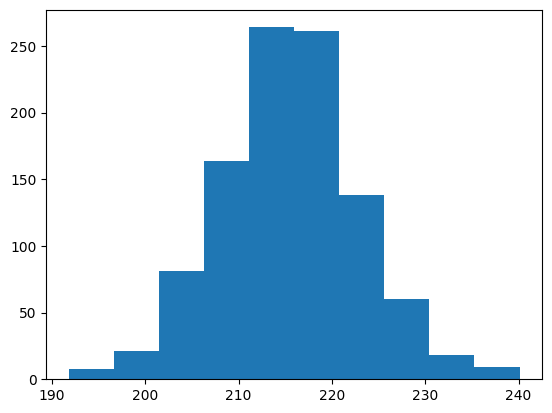

In [11]:
plt.hist(y);

## 4. Reconstruct image from measurements

Can we reconstruct the original input image - from this???

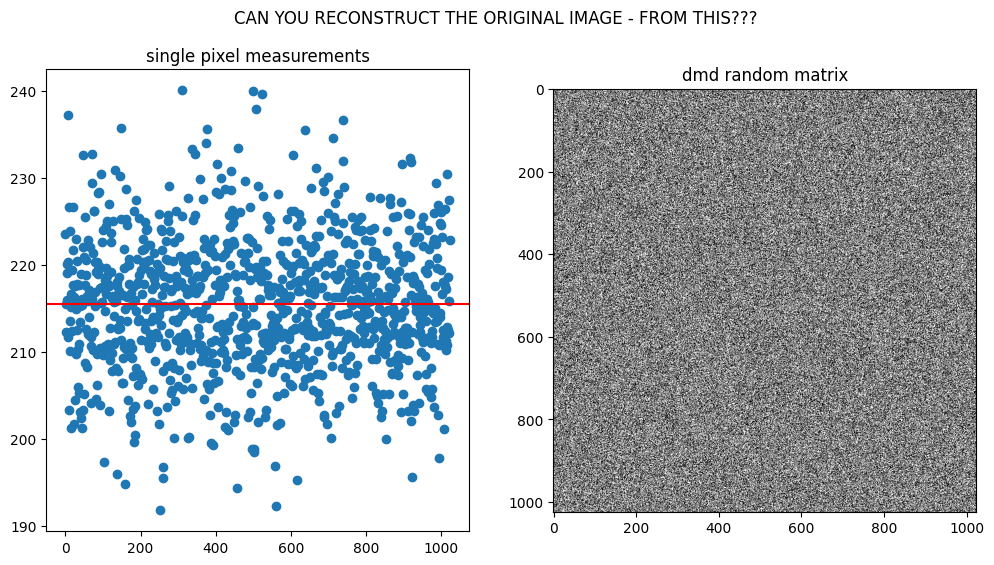

In [19]:
fig, axs = plt.subplots(1,2, figsize=(12, 6))

axs[0].scatter(np.arange(len(y)), y)
axs[0].set_title("single pixel measurements")
axs[0].axhline(y.mean(), c="red")

axs[1].imshow(phi, cmap="binary", vmin=0, vmax=1)
axs[1].set_title("dmd random matrix")

fig.suptitle("CAN YOU RECONSTRUCT THE ORIGINAL IMAGE - FROM THIS???")

plt.show();

Single-Pixel Imaging:

$$
    y = \Phi x
$$

Linear Regression:

$$
    y = X \beta
$$

## 

In [12]:
model = LinearRegression()
model.fit(phi, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


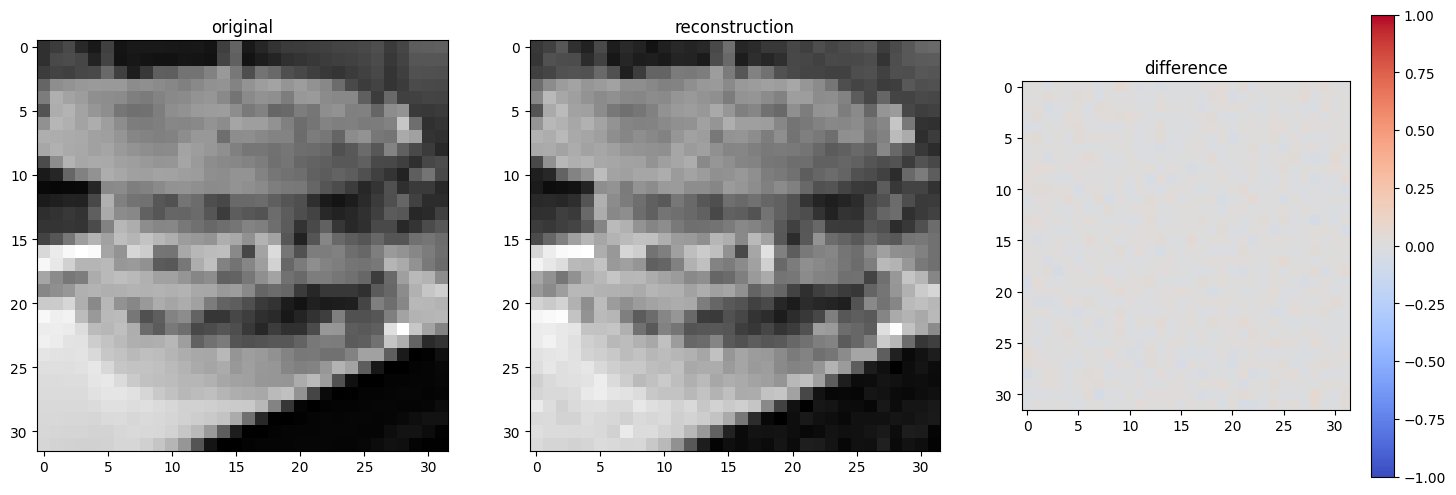

In [13]:
fig, axs = plt.subplots(1,3, figsize=(18, 6))

axs[0].imshow(x.reshape(32,32), cmap="grey")
axs[0].set_title("original")

axs[1].imshow(model.coef_.reshape(32,32), cmap="grey")
axs[1].set_title("reconstruction");

im = axs[2].imshow((x - model.coef_).reshape(32,32), cmap="coolwarm", vmin=-1, vmax=1)
axs[2].set_title("difference");

plt.colorbar(im)